# BNY Corporate-Actions EDA

**Question:** How well can *public* corporate-action documents populate the fields required in a real BNY client notification?

**Canonical target:** BNY notification schema (`src/eda/bny_schema.py`)

**Public corpus (this run):** SEC EDGAR tender-related filings via EFTS — `SC TO-T`, `SC TO-T/A`, `SC TO-I`, `SC TO-I/A`, `SC 14D9`, `SC 14D9/A` (2020–2025).

### Evidence discipline
| Label | Meaning |
|-------|---------|
| **Observed** | Present in EFTS metadata or successful document download/parse |
| **Inferred** | Regex mention detection / heuristic derivation |
| **Internal** | Definitionally unavailable from public documents |
| **N/A** | Not relevant for an event type (assumption, labeled) |

Missing scalars → conceptually `null`. Missing lists (e.g. `available_options`) → conceptually `[]`.  
`notification_type` is kept **separate** from `corporate_action_type`.


In [1]:
from pathlib import Path
import sys, warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from eda.corpus import load_corpus
from eda.overview import summarize_dataset, overview_tables, plot_form_distribution, plot_temporal_volume
from eda.events import analyze_events, plot_event_distributions
from eda.documents import analyze_documents, plot_format_distribution, sample_documents_for_content
from eda.schema_coverage import analyze_schema_coverage
from eda.amendments import analyze_amendments
from eda.quality import analyze_data_quality
from eda.missingness import classify_missingness, ground_truth_recommendations
from eda.mvp import recommend_mvp_design
from eda.bny_schema import BNY_SCHEMA
from eda.config import PROCESSED_DIR, FIGURES_DIR

OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
(OUTPUTS / 'figures').mkdir(exist_ok=True)
print('fields in BNY schema:', len(BNY_SCHEMA))


fields in BNY schema: 39


## 1. Dataset overview

In [2]:
docs, events = load_corpus()
overview = summarize_dataset(docs, events)
tables = overview_tables(docs, events)
display(tables['summary'])
display(tables['form_counts'])
display(tables['family_counts'])
print(overview['source_note'])
print(f"Events with multiple documents: {(events['n_documents']>1).sum()} ({100*(events['n_documents']>1).mean():.1f}%)")
print(f"Events with amendments: {int(events['has_amendment'].sum())} ({overview['pct_events_with_amendments']}%)")


,metric,value
0,documents,32046
1,filings (unique accession),9364
2,events (by SEC file number),893
3,date_min,2020-01-02
4,date_max,2025-12-31
5,events_with_amendments,870
6,pct_events_with_amendments,97.42


,form,n_documents
0,SC TO-I,17893
1,SC TO-I/A,6495
2,SC TO-T,2844
3,SC TO-T/A,2388
4,SC 14D9/A,1474
5,SC 14D9,952


,form_family,n_documents
0,issuer_tender,24388
1,third_party_tender,5232
2,target_recommendation,2426


Document rows are EFTS hit-level records (primary filing docs + indexed exhibits). Events are grouped by SEC file number (primary_file_num) when present.
Events with multiple documents: 884 (99.0%)
Events with amendments: 870 (97.42%)


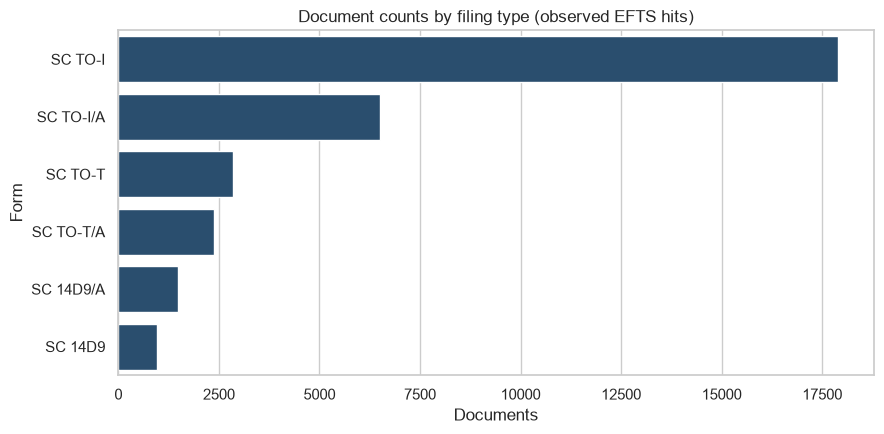

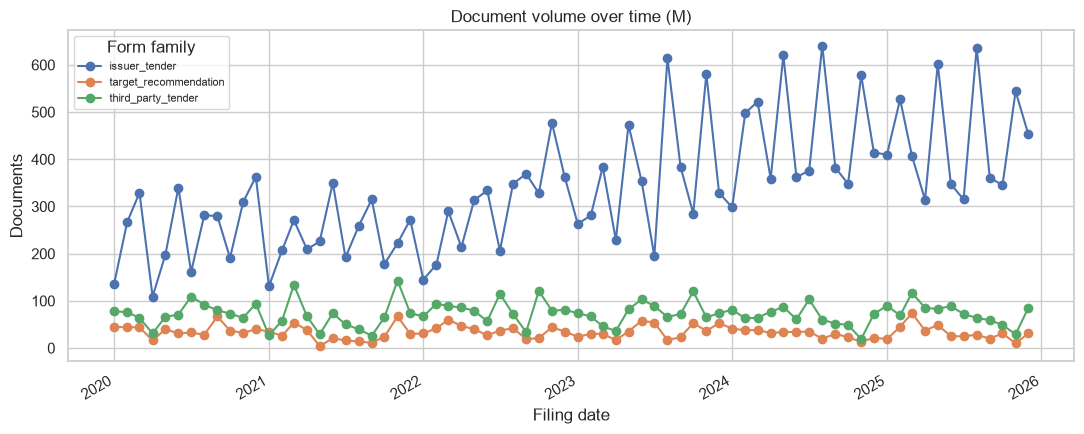

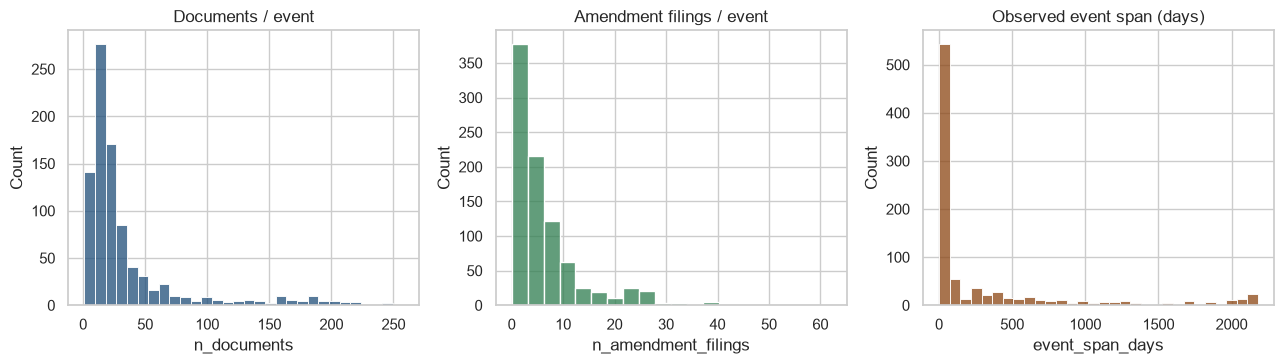

In [3]:
fig = plot_form_distribution(docs); plt.show()
fig = plot_temporal_volume(docs); plt.show()
fig = plot_event_distributions(events); plt.show()


In [4]:
event_stats = analyze_events(docs, events)
display(event_stats['unusual_document_volume'].head(10))
display(event_stats['unusual_amendment_volume'].head(10))
display(event_stats['repeated_issuers'].head(15))
print(event_stats['note'])


,event_id,primary_entity,primary_form_family,n_documents,n_filings,n_amendment_filings,event_span_days
447,005-88884,"CPG Carlyle Commitments Fund, LLC",issuer_tender,258,47,25,2077
344,005-87063,AB Multi-Manager Alternative Fund,issuer_tender,248,49,25,2120
424,005-88370,"NexPoint Capital, Inc.",issuer_tender,241,51,27,2180
293,005-85837,Partners Group Private Equity,issuer_tender,224,48,25,2132
501,005-89919,Pomona Investment Fund,issuer_tender,223,50,26,2178
523,005-90234,"Carlyle Credit Solutions, Inc.",mixed,220,48,31,1357
655,005-91801,Blackstone Private Credit Fund,issuer_tender,218,50,31,1682
172,005-80363,Alpha Core Strategies Fund,issuer_tender,214,49,25,2127
488,005-89754,Peachtree Alternative Strategies Fund,issuer_tender,212,48,24,2157
462,005-89250,ABS Long/Short Strategies Fund,issuer_tender,207,47,23,2113


,event_id,primary_entity,primary_form_family,n_documents,n_filings,n_amendment_filings,event_span_days
503,005-89940,"Southwest Gas Holdings, Inc.",mixed,158,64,62,208
170,005-80234,BEACON ROOFING SUPPLY INC,mixed,133,56,54,92
58,005-42593,SEACOR HOLDINGS INC /NEW/,mixed,92,43,40,118
358,005-87285,STRATASYS LTD.,mixed,178,41,39,68
302,005-86024,Wright Medical Group N.V.,mixed,67,38,38,315
445,005-88851,"Priority Income Fund, Inc.",issuer_tender,176,60,38,2093
483,005-89626,"F-star Therapeutics, Inc.",mixed,78,40,38,245
567,005-90752,AIP Alternative Lending Fund A,issuer_tender,206,59,35,2100
744,005-93360,Olink Holding AB,mixed,97,37,35,260
438,005-88663,Santander Consumer USA Holdings Inc.,mixed,68,37,33,729


,entity,n_events
0,GROSVENOR REGISTERED MULTI-STRATEGY FUND,2


Event duration is observed as last_file_date - first_file_date for documents sharing a SEC file number. Offer expiration is NOT inferred here.


## 2. BNY schema coverage analysis

Text-field percentages are **inferred** from regex presence on a stratified download sample and are **not** extraction accuracy.
Internal fields are definitionally 0% public coverage.


In [5]:
sample_path = PROCESSED_DIR / 'content_sample.parquet'
if sample_path.exists():
    content_sample = pd.read_parquet(sample_path)
else:
    content_sample = sample_documents_for_content(docs, n_per_form=8)
    content_sample.to_parquet(sample_path, index=False)
print(content_sample.groupby(['form','status']).size())
coverage = analyze_schema_coverage(docs, events, content_sample)
print(coverage['note'])
display(coverage['schema_coverage'][[
    'field','public_coverage_pct','missing_pct','primary_source',
    'explicit_or_derived','difficulty','evidence_type','denominator_note'
]])
coverage['schema_coverage'].to_csv(OUTPUTS / 'schema_coverage.csv', index=False)


form       status
SC 14D9    ok        10
SC 14D9/A  ok        10
SC TO-I    ok        10
SC TO-I/A  ok        10
SC TO-T    ok        10
SC TO-T/A  ok        10
dtype: int64
Text-field coverage percentages are inferred from regex presence on downloaded sample documents covering 38 events. They measure mention detection, not successful structured extraction. Internal-only fields are definitionally 0% public coverage.


,field,public_coverage_pct,missing_pct,primary_source,explicit_or_derived,difficulty,evidence_type,denominator_note
0,notification_family,100.00,0.00,SC 14D9,derived,low,inferred_regex_presence,sample_events_with_downloaded_text
1,notification_type,73.68,26.32,SC 14D9,derived,medium,inferred_regex_presence,sample_events_with_downloaded_text
2,notification_status,97.37,2.63,SC 14D9/A,derived,medium,inferred_regex_presence,sample_events_with_downloaded_text
3,processing_status,0.00,100.00,internal BNY,internal,n/a,internal_only,all_events_definitional_zero
4,mandatory_voluntary_indicator,5.26,94.74,SC 14D9,explicit,medium,inferred_regex_presence,sample_events_with_downloaded_text
5,security_description,100.00,0.00,EFTS entity_name / filing text,explicit,low,observed_metadata,all_events_metadata
6,isin,0.00,100.00,SC 14D9,explicit,low,inferred_regex_presence,sample_events_with_downloaded_text
7,cusip,97.37,2.63,SC 14D9,explicit,low,inferred_regex_presence,sample_events_with_downloaded_text
8,ticker,51.18,48.82,EFTS display_names (metadata),explicit,low,observed_metadata,all_events_metadata; sample_text_detection_pct=34.2
9,currency,13.16,86.84,SC 14D9,explicit,low,inferred_regex_presence,sample_events_with_downloaded_text


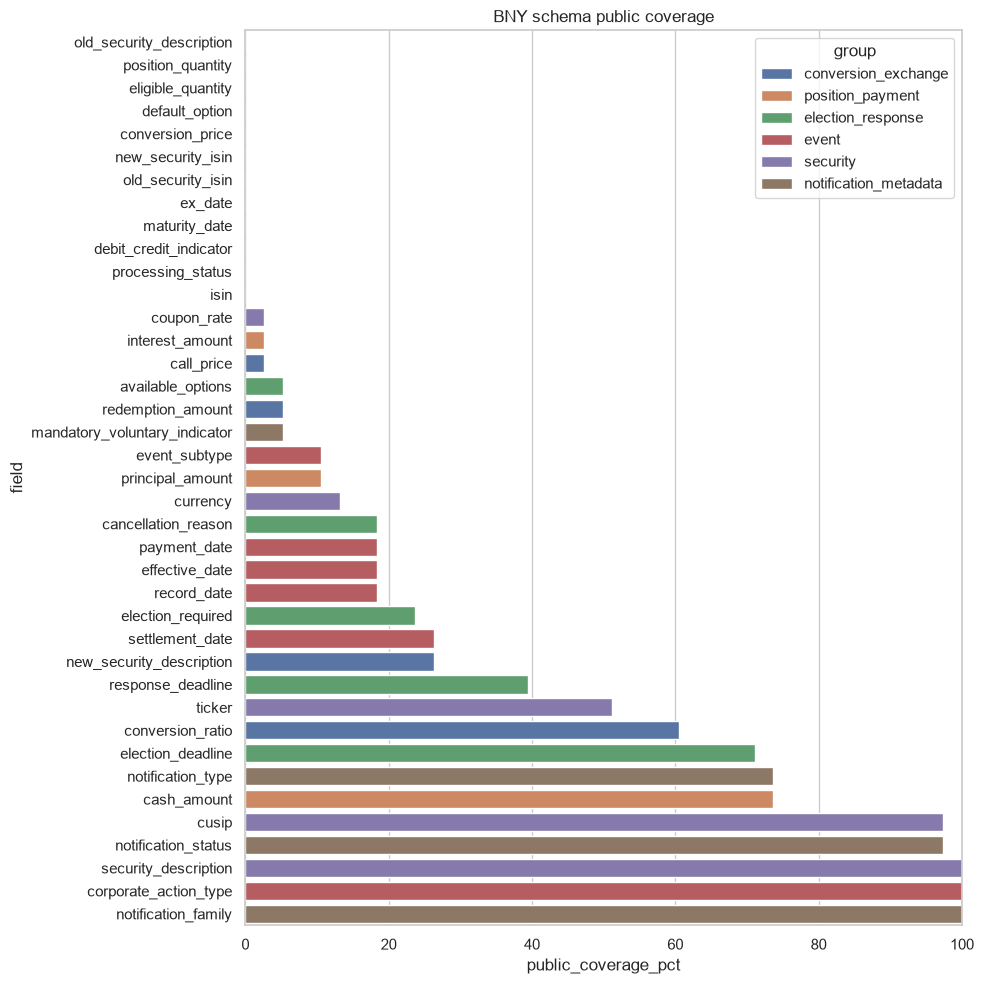

In [6]:
cov = coverage['schema_coverage'].dropna(subset=['public_coverage_pct']).sort_values('public_coverage_pct')
fig, ax = plt.subplots(figsize=(10,10))
sns.barplot(data=cov, y='field', x='public_coverage_pct', hue='group', dodge=False, ax=ax)
ax.set_xlim(0,100); ax.set_title('BNY schema public coverage')
fig.tight_layout(); fig.savefig(OUTPUTS/'figures'/'schema_coverage.png', dpi=150); plt.show()


## 3. Public vs internal field classification

In [7]:
cls = coverage['schema_coverage'].groupby('source_class').size().rename('n_fields').reset_index()
display(cls)
display(coverage['schema_coverage'][['field','source_class','ground_truth_class','relevance_note']])


,source_class,n_fields
0,bny_internal_only,4
1,derived_from_public,5
2,public_document_extractable,26
3,unclear_requires_investigation,4


,field,source_class,ground_truth_class,relevance_note
0,notification_family,derived_from_public,weak_heuristic,"Can be mapped from corporate-action family (e.g., tender/offer) but is a BNY taxonomy label."
1,notification_type,derived_from_public,requires_manual_annotation,BNY notification_type is distinct from corporate_action_type; needs mapping table.
2,notification_status,derived_from_public,weak_heuristic,Approximated from initial vs /A filings and cancellation/withdrawal language.
3,processing_status,bny_internal_only,cannot_evaluate_from_public,BNY workflow state; not present in public SEC filings.
4,mandatory_voluntary_indicator,public_document_extractable,requires_manual_annotation,Often stated for tenders (voluntary) but wording varies.
5,security_description,public_document_extractable,weak_heuristic,Usually in cover page / offer title; also partly in EFTS display names.
6,isin,public_document_extractable,requires_manual_annotation,Present in many offer docs but not in EFTS metadata.
7,cusip,public_document_extractable,requires_manual_annotation,Common in U.S. tender materials.
8,ticker,public_document_extractable,weak_heuristic,Sometimes in EFTS display_names; otherwise in document text.
9,currency,public_document_extractable,weak_heuristic,Often USD implied for U.S. cash tenders; explicit currency labels vary.


## 4. Corporate-action-type × field coverage

,corporate_action_type,field,coverage_pct,n_sample_events,relevance_assumption,evidence_type
0,issuer_tender,notification_family,100.00,19,relevant,inferred_regex_presence
1,issuer_tender,notification_type,73.68,19,relevant,inferred_regex_presence
2,issuer_tender,notification_status,100.00,19,relevant,inferred_regex_presence
3,issuer_tender,processing_status,0.00,19,not_relevant,internal_only
4,issuer_tender,mandatory_voluntary_indicator,0.00,19,relevant,inferred_regex_presence
5,issuer_tender,security_description,84.21,19,relevant,inferred_regex_presence
6,issuer_tender,isin,0.00,19,relevant,inferred_regex_presence
7,issuer_tender,cusip,94.74,19,relevant,inferred_regex_presence
8,issuer_tender,ticker,15.79,19,relevant,inferred_regex_presence
9,issuer_tender,currency,0.00,19,relevant,inferred_regex_presence


corporate_action_type,issuer_tender,mixed,third_party_tender
field,,,
available_options,5.26,5.88,0.0
call_price,0.00,5.88,0.0
cancellation_reason,0.00,41.18,0.0
cash_amount,52.63,100.00,50.0
conversion_price,0.00,0.00,0.0
conversion_ratio,47.37,82.35,0.0
corporate_action_type,100.00,100.00,100.0
coupon_rate,0.00,5.88,0.0
currency,0.00,29.41,0.0


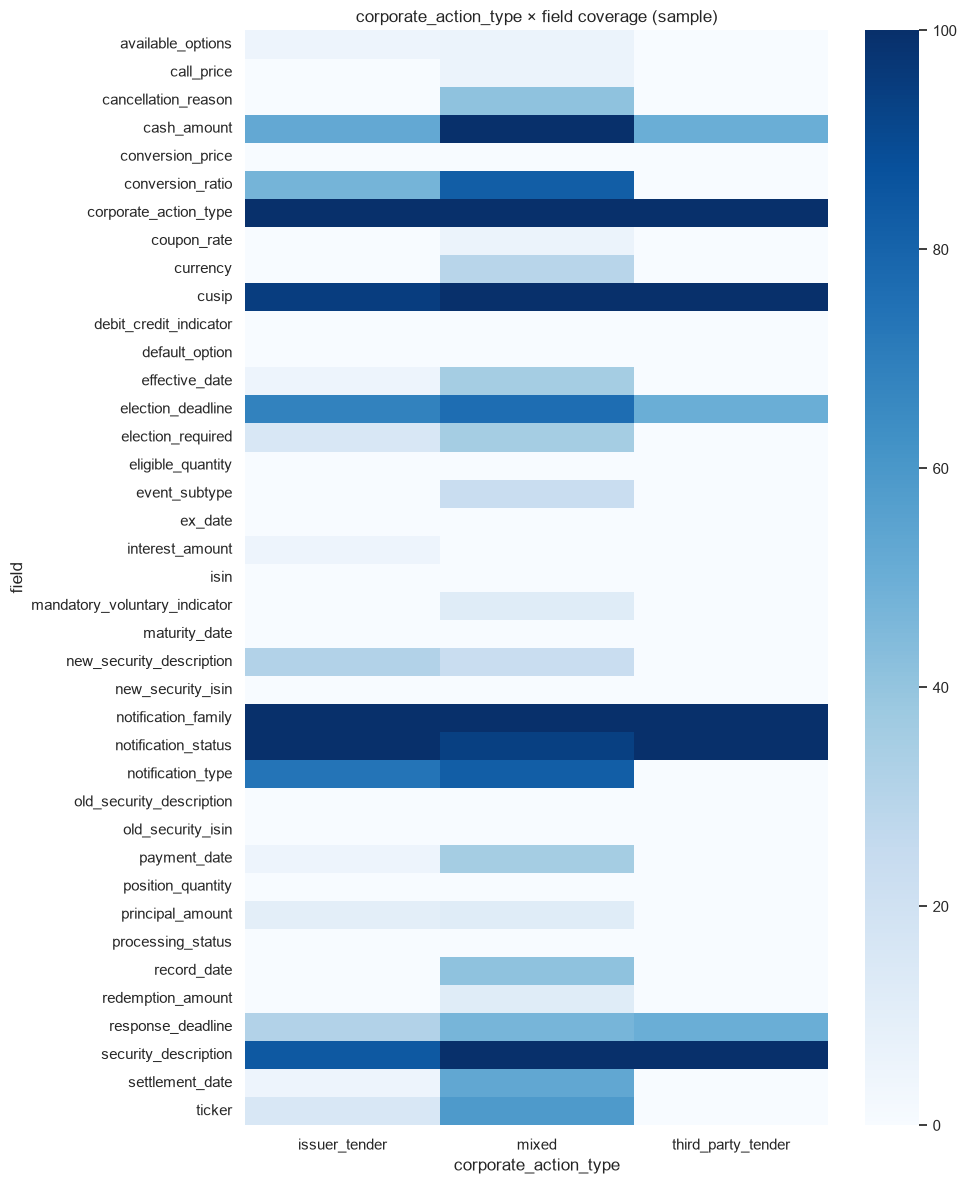

In [8]:
etc = coverage['event_type_coverage']
display(etc.head(50))
etc.to_csv(OUTPUTS / 'event_type_coverage.csv', index=False)
if not etc.empty:
    pivot = etc.pivot_table(index='field', columns='corporate_action_type', values='coverage_pct')
    display(pivot)
    fig, ax = plt.subplots(figsize=(10,12))
    sns.heatmap(pivot, cmap='Blues', vmin=0, vmax=100, ax=ax)
    ax.set_title('corporate_action_type × field coverage (sample)')
    fig.tight_layout(); fig.savefig(OUTPUTS/'figures'/'event_type_coverage_heatmap.png', dpi=150); plt.show()


## 5. Document characteristics

,format,n
0,html,32040
1,pdf,5
2,text,1


,field,n_missing,pct_missing
0,filename,0,0.0
1,primary_cik,0,0.0
2,primary_file_num,0,0.0
3,entity_name,0,0.0
4,file_date,0,0.0


,status,n
0,ok,60


,words,tokens_whitespace,pages_approx_500w,n_html_tables,table_word_share
form,,,,,
SC 14D9,31414.9,31414.9,62.83,85.4,0.16
SC 14D9/A,1556.3,1556.3,3.11,6.8,0.14
SC TO-I,3092.5,3092.5,6.19,20.4,0.30
SC TO-I/A,1062.7,1062.7,2.13,9.5,0.34
SC TO-T,2556.2,2556.2,5.11,21.2,0.27
SC TO-T/A,1582.2,1582.2,3.16,9.9,0.30


Page/word/token stats require document downloads. When content_sample is provided, length metrics are sample-observed only.


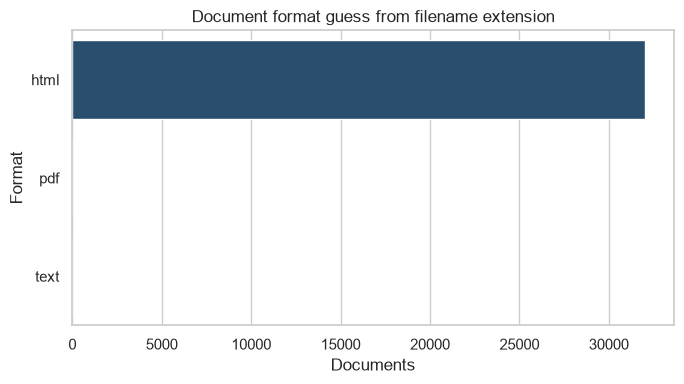

In [9]:
doc_stats = analyze_documents(docs, content_sample)
display(doc_stats['format_distribution'])
display(doc_stats['missing_core_fields'])
display(doc_stats['sample_status_counts'])
ok = content_sample[content_sample['status']=='ok']
if not ok.empty:
    display(ok.groupby('form')[['words','tokens_whitespace','pages_approx_500w','n_html_tables','table_word_share']].mean(numeric_only=True).round(2))
print(doc_stats['note'])
fig = plot_format_distribution(docs); plt.show()


## 6. Temporal / amendment analysis

In [10]:
amend = analyze_amendments(docs, events, content_sample)
print(f"Events with amendments: {amend['n_events_with_amendments']} ({amend['pct_events_with_amendments']}%)")
display(amend['simple_amendment_examples'])
display(amend['complex_amendment_examples'])
display(amend['field_presence_delta_summary'])
print(amend['note'])
print('Lifecycle model: initial state → amendment(s) → final/completed/cancelled (do not overwrite prior values).')


Events with amendments: 870 (97.42%)


,event_id,primary_entity,primary_form_family,n_filings,n_amendment_filings,n_documents,event_span_days,first_file_date,last_file_date
64,005-43608,ASURE SOFTWARE INC,issuer_tender,1,1,1,0,2020-01-29,2020-01-29
184,005-81011,"Mellon Optima L/S Strategy Fund, LLC",issuer_tender,1,1,1,0,2020-02-07,2020-02-07
337,005-86989,Blackstone Alternative Alpha Master Fund,issuer_tender,1,1,1,0,2020-03-09,2020-03-09
338,005-86990,Blackstone Alternative Alpha Fund,issuer_tender,1,1,1,0,2020-03-09,2020-03-09
376,005-87619,Blackstone Alternative Alpha Fund II,issuer_tender,1,1,1,0,2020-03-09,2020-03-09
404,005-88059,Grosvenor Registered Multi-Strategy Fund,issuer_tender,1,1,1,0,2020-02-10,2020-02-10
606,005-91208,"Hartman Short Term Income Properties XX, Inc.",third_party_tender,1,1,1,0,2020-01-07,2020-01-07
75,005-46803,WINMARK CORP,issuer_tender,1,1,2,0,2020-01-17,2020-01-17
96,005-51837,SSR MINING INC.,issuer_tender,1,1,2,0,2020-02-03,2020-02-03
451,005-88918,Gannett Media Corp.,issuer_tender,1,1,2,0,2020-01-02,2020-01-02


,event_id,primary_entity,primary_form_family,n_filings,n_amendment_filings,n_documents,event_span_days,first_file_date,last_file_date
503,005-89940,"Southwest Gas Holdings, Inc.",mixed,64,62,158,208,2021-10-27,2022-05-23
170,005-80234,BEACON ROOFING SUPPLY INC,mixed,56,54,133,92,2025-01-27,2025-04-29
58,005-42593,SEACOR HOLDINGS INC /NEW/,mixed,43,40,92,118,2020-12-18,2021-04-15
358,005-87285,STRATASYS LTD.,mixed,41,39,178,68,2023-05-25,2023-08-01
302,005-86024,Wright Medical Group N.V.,mixed,38,38,67,315,2020-01-02,2020-11-12
445,005-88851,"Priority Income Fund, Inc.",issuer_tender,60,38,176,2093,2020-01-27,2025-10-20
483,005-89626,"F-star Therapeutics, Inc.",mixed,40,38,78,245,2022-07-07,2023-03-09
567,005-90752,AIP Alternative Lending Fund A,issuer_tender,59,35,206,2100,2020-04-01,2025-12-31
744,005-93360,Olink Holding AB,mixed,37,35,97,260,2023-10-31,2024-07-17
438,005-88663,Santander Consumer USA Holdings Inc.,mixed,37,33,68,729,2020-01-30,2022-01-28


,field,n_pairs_with_presence_delta
0,restrictions,2


Amendment counts are observed from form suffixes (/A) and filing dates. Field-level change analysis requires paired sample texts and is inferred only. Sample contained 2 initial/amendment pairs with downloadable text.
Lifecycle model: initial state → amendment(s) → final/completed/cancelled (do not overwrite prior values).


## 7. Missingness analysis

In [11]:
miss = classify_missingness(coverage['schema_coverage'], coverage['event_type_coverage'])
display(miss)
miss.to_csv(OUTPUTS / 'missingness_taxonomy.csv', index=False)


,field,group,public_coverage_pct,missingness_class,source_class,ground_truth_class,evidence_type
0,notification_family,notification_metadata,100.00,usually_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
1,notification_type,notification_metadata,73.68,sometimes_present_in_public_sample,derived_from_public,requires_manual_annotation,inferred_regex_presence
2,notification_status,notification_metadata,97.37,usually_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
3,processing_status,notification_metadata,0.00,internal_bny_only,bny_internal_only,cannot_evaluate_from_public,internal_only
4,mandatory_voluntary_indicator,notification_metadata,5.26,likely_relevant_but_rarely_detected,public_document_extractable,requires_manual_annotation,inferred_regex_presence
5,security_description,security,100.00,usually_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
6,isin,security,0.00,likely_relevant_but_rarely_detected,public_document_extractable,requires_manual_annotation,inferred_regex_presence
7,cusip,security,97.37,usually_present_in_public_sample,public_document_extractable,requires_manual_annotation,inferred_regex_presence
8,ticker,security,51.18,sometimes_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
9,currency,security,13.16,likely_relevant_but_rarely_detected,public_document_extractable,weak_heuristic,inferred_regex_presence


## 8. Ground-truth feasibility

In [12]:
gt = ground_truth_recommendations(coverage['schema_coverage'])
display(gt)
gt.to_csv(OUTPUTS / 'ground_truth_feasibility.csv', index=False)


,field,group,public_coverage_pct,ground_truth_class,difficulty,benchmark_recommendation,evidence_type
26,call_price,conversion_exchange,2.63,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
24,conversion_price,conversion_exchange,0.00,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
21,new_security_description,conversion_exchange,26.32,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
22,new_security_isin,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
19,old_security_description,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
20,old_security_isin,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
25,redemption_amount,conversion_exchange,5.26,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
28,available_options,election_response,5.26,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
32,cancellation_reason,election_response,18.42,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
29,default_option,election_response,0.00,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence


## 9. Dataset splitting and leakage

In [13]:
quality = analyze_data_quality(docs, events)
display(quality['leakage_risks'])
display(quality['missing_metadata'])
mvp = recommend_mvp_design(docs, events)
display(mvp['split_table'])
print(mvp['split_policy'])


,risk,affected_events,affected_documents,recommendation
0,document_level_random_split,884,32037.0,"Split by event_id (SEC file number), not by document/accession."
1,issuer_repeated_across_splits,22,NaN,Consider issuer/CIK-aware splits for generalization tests.
2,weak_event_key_without_file_num,0,0.0,Manually review fallback event keys before amendment evaluation.


,field,n_missing_or_empty,pct
0,accession,0,0.0
1,filename,0,0.0
2,form,0,0.0
3,file_date,0,0.0
4,primary_cik,0,0.0
5,entity_name,0,0.0
6,primary_file_num,0,0.0
7,tickers,0,0.0


,split,target_fraction,approx_events_if_mvp
0,train,0.70,200
1,validation,0.15,43
2,test,0.15,43


Always split by event_id (SEC file number). Never by document. Keep all amendments with the parent event. Optionally hold out entire issuers (CIK) for a generalization fold.


## 10. Implications for MVP Design

See `EDA_SUMMARY.md` for the written recommendations answering:
1. Which corporate-action types to start with
2. Which BNY fields can be automated from public data
3. Which fields need BNY/internal data
4. Which need manual annotation
5. Best amendment examples
6. First extraction benchmark field subset
7. Sufficiency for extraction / notification generation / amendment detection / grounding


In [14]:
# Persist required reports
quality['missing_metadata'].assign(section='missing_metadata').to_csv(OUTPUTS/'data_quality_report.csv', index=False)
print('Primary outputs directory:', OUTPUTS)
print('Or re-run: python scripts/run_eda.py')


Primary outputs directory: /Users/kedarvaidya/Desktop/BNY-Capstone-Project/outputs
Or re-run: python scripts/run_eda.py
